In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures,StandardScaler


In [2]:
#data load
df=pd.read_csv("encoded_car_data (1).csv")
df.head()

,diesel,gas,std,turbo,convertible,hardtop,hatchback,sedan,wagon,4wd,...,wheelbase,curbweight,enginesize,boreratio,horsepower,carlength,carwidth,citympg,highwaympg,price
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,13495.0
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,16500.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,94.5,2823.0,152.0,2.68,154.0,171.2,65.5,19.0,26.0,16500.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,99.8,2337.0,109.0,3.19,102.0,176.6,66.2,24.0,30.0,13950.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,99.4,2824.0,136.0,3.19,115.0,176.6,66.4,18.0,22.0,17450.0


In [3]:
# select features and target 
x=df[['enginesize','horsepower','citympg','highwaympg']]
y=df['price']

In [4]:
#Spliting data set
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
# 1.Linear Regression (With scaling)
lr=Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
])
lr.fit(x_train,y_train)
y_pred_linear=lr.predict(x_test)

In [6]:
# 2.Polynomial Regression (Degree=2)
poly_model=Pipeline([
    ('poly',PolynomialFeatures(degree=2)),
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
    
])
poly_model.fit(x_train,y_train)
y_pred_poly=poly_model.predict(x_test)

In [7]:
#Evaluat models
print('Name: Athreya A')
print('Reg No:212225240016')
print('Linear Regression')


Name: Athreya A
Reg No:212225240016
Linear Regression


In [8]:
#MSE=Mean squared error
print('MSE:',mean_squared_error(y_test,y_pred_linear))
print('R2 squ:',r2_score(y_test,y_pred_linear))
print('MAE:',mean_absolute_error(y_test,y_pred_linear))

MSE: 16471505.900042146
R2 squ: 0.7913520781370976
MAE: 2892.628134137953


In [9]:
print("Polynomial Regression")
print('MSE:',mean_squared_error(y_test,y_pred_poly))
print('R2 squ:',r2_score(y_test,y_pred_poly))
print('MAE:',mean_absolute_error(y_test,y_pred_poly))

Polynomial Regression
MSE: 15247661.892213836
R2 squ: 0.806854759583916
MAE: 2694.0456913330454


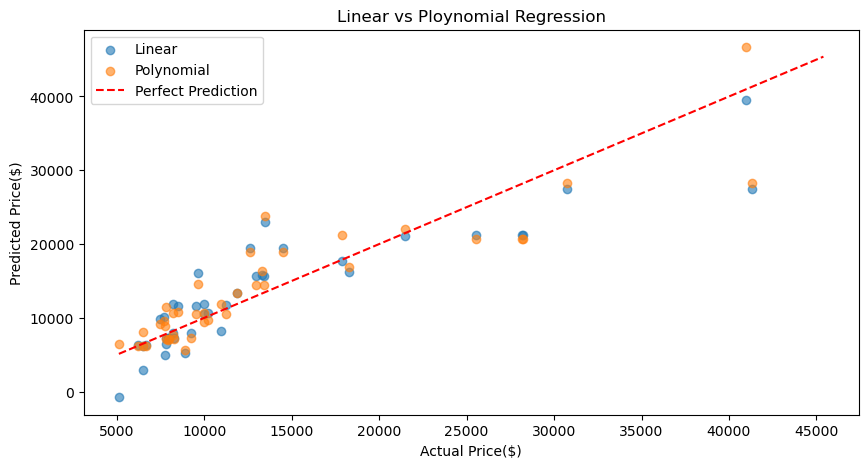

In [10]:
#Ploting graph
plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred_linear,label='Linear',alpha=0.6)
plt.scatter(y_test,y_pred_poly,label='Polynomial',alpha=0.6)
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--',label='Perfect Prediction')
plt.title('Linear vs Ploynomial Regression')
plt.xlabel('Actual Price($)')
plt.ylabel('Predicted Price($)')
plt.legend()
plt.show()